In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [9]:
iris=load_iris()
x=StandardScaler().fit_transform(iris.data)

db=DBSCAN(eps=0.85,min_samples=3).fit(x)
labels=db.labels_
labels


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [12]:
n_clusters=len(set(labels))-(1 if -1 in labels else 0)
n_noise=(labels==-1).sum()
print(f"Clusters:{n_clusters}")
print(f"Noise Points:{n_noise}")

Clusters:2
Noise Points:4


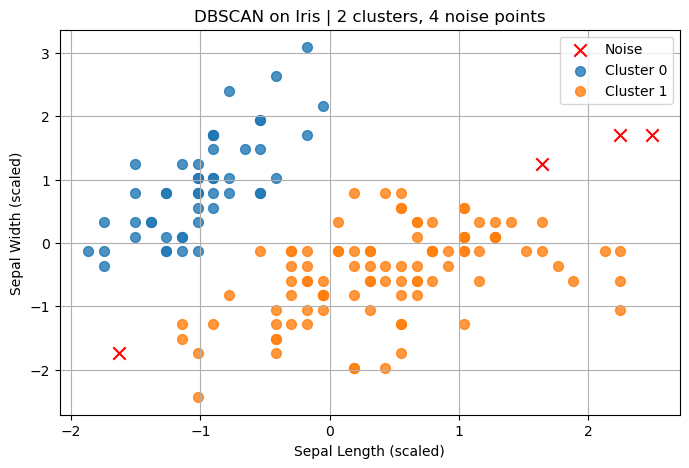

In [14]:
import matplotlib.pyplot as plt

# Plot (using first 2 features: sepal length vs sepal width)
plt.figure(figsize=(8, 5))

for label in sorted(set(labels)):
    mask = labels == label

    if label == -1:
        plt.scatter(
            x[mask, 0],
            x[mask, 1],
            c='red',
            marker='x',
            s=80,
            label='Noise'
        )
    else:
        plt.scatter(
            x[mask, 0],
            x[mask, 1],
            s=50,
            alpha=0.8,
            label=f'Cluster {label}'
        )

plt.title(f"DBSCAN on Iris | {n_clusters} clusters, {n_noise} noise points")
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.legend()
plt.grid(True)
plt.show()